In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [3]:
f_pd = uproot.open("/pscratch/sd/k/kgreif/data/Pseudodata_WithSherapaNoReweighting_12May2025_topLogit.root")
t_pd = f_pd["OmniTree"]

pass190_pd = ak.to_numpy(t_pd["pass190"].array())
is_top_pd = ak.to_numpy(t_pd["isTop"].array())
logit_pd = ak.to_numpy(t_pd["isTop_logit"].array())

logit_pd = logit_pd[pass190_pd == 1]

In [4]:
f_top = uproot.open("/pscratch/sd/k/kgreif/data/ZjetOmnifold_14May2025_Background_Sherpa2212_AllTop_WithTracks_slim_Systematics_topLogit.root")
t_top = f_top["OmniTree"]

pass190_top = ak.to_numpy(t_top["pass190"].array())
logit_top = ak.to_numpy(t_top["isTop_logit"].array())
weight_top = ak.to_numpy(t_top["weight"].array())

logit_top = logit_top[pass190_top == 1]
weight_top = weight_top[pass190_top == 1]

In [5]:
logit_pd_minus_top = np.concatenate([logit_pd, logit_top])
weights_pd_minus_top = np.concatenate([np.ones(len(logit_pd)), -1 * weight_top])

In [21]:
reweighting_sub10 = np.load("golden-jazz-sub10.npz")
new_weights_sub10 = reweighting_sub10["reweighting"]

reweighting_add9 = np.load("summer-microwave-add9.npz")
new_weights_add9 = reweighting_add9["reweighting"]

final_weights = new_weights_sub10 + new_weights_add9

In [22]:
print(f"Mean of sub10: {np.mean(new_weights_sub10)}")
print(f"Mean of add9: {np.mean(new_weights_add9)}")
print(f"Mean of final: {np.mean(final_weights)}")


Mean of sub10: 0.973382830619812
Mean of add9: 0.018460920080542564
Mean of final: 0.9918438792228699


In [23]:
bins = np.linspace(logit_pd.min(), logit_pd.max(), 100)
h_logit_pd, _ = np.histogram(logit_pd, bins=bins, density=True)
h_logit_pd_minus_top, _ = np.histogram(logit_pd_minus_top, bins=bins, density=True, weights=weights_pd_minus_top)
h_logit_pd_rw, _ = np.histogram(logit_pd, bins=bins, density=True, weights=final_weights)

plot_h_logit_pd = np.concatenate([h_logit_pd, h_logit_pd[-1:]])
plot_h_logit_pd_minus_top = np.concatenate([h_logit_pd_minus_top, h_logit_pd_minus_top[-1:]])
plot_h_logit_pd_rw = np.concatenate([h_logit_pd_rw, h_logit_pd_rw[-1:]])

/tmp/ipykernel_1588342/917523911.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


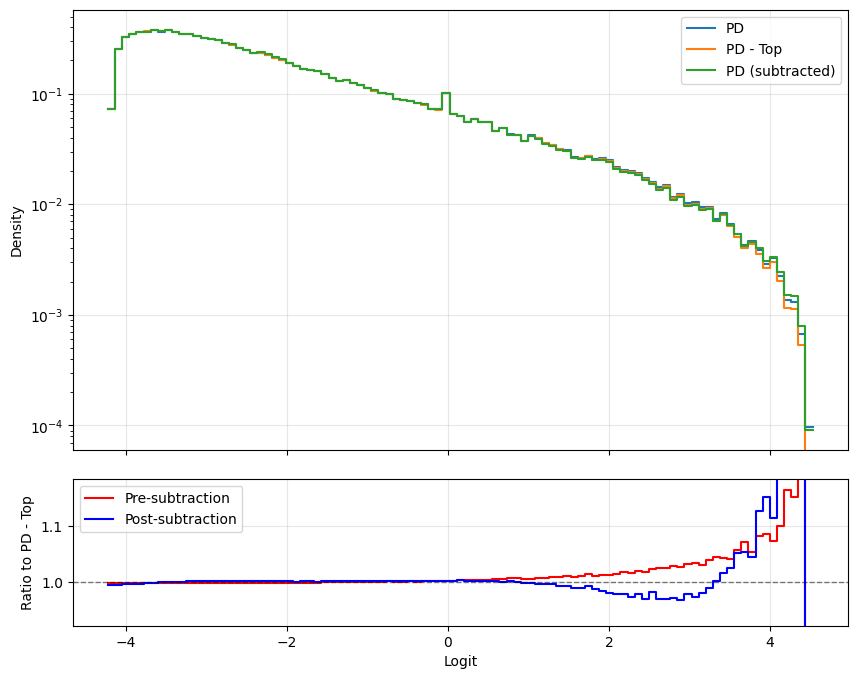

In [24]:
# Create figure with two subplots: main plot and ratio pad
fig, (ax_main, ax_ratio) = plt.subplots(
    2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 1], "hspace": 0.1}
)

# Main histogram plot
ax_main.plot(bins, plot_h_logit_pd, drawstyle="steps-post", label="PD")
ax_main.plot(bins, plot_h_logit_pd_minus_top, drawstyle="steps-post", label="PD - Top")
ax_main.plot(bins, plot_h_logit_pd_rw, drawstyle="steps-post", label="PD (subtracted)")
ax_main.set_yscale("log")
ax_main.legend()
ax_main.set_ylabel("Density")
ax_main.grid(True, alpha=0.3)

# Remove x-axis labels from main plot
ax_main.set_xticklabels([])

# Calculate ratio (avoid division by zero)
ratio_pre = np.divide(
    plot_h_logit_pd,
    plot_h_logit_pd_minus_top,
    out=np.zeros_like(plot_h_logit_pd_minus_top),
    where=plot_h_logit_pd_minus_top != 0,
)
ratio_post = np.divide(
    plot_h_logit_pd_rw,
    plot_h_logit_pd_minus_top,
    out=np.zeros_like(plot_h_logit_pd_minus_top),
    where=plot_h_logit_pd_minus_top != 0,
)

# Ratio pad
ax_ratio.plot(bins, ratio_pre, drawstyle="steps-post", color="red", linewidth=1.5, label="Pre-subtraction")
ax_ratio.plot(bins, ratio_post, drawstyle="steps-post", color="blue", linewidth=1.5, label="Post-subtraction")
ax_ratio.axhline(y=1, color="black", linestyle="--", alpha=0.5, linewidth=1)
ax_ratio.set_ylabel("Ratio to PD - Top")
ax_ratio.set_xlabel("Logit")
ax_ratio.grid(True, alpha=0.3)
ax_ratio.legend()

# Set reasonable y-limits for ratio (adjust as needed)
ratio_nonzero_pre = ratio_pre[ratio_pre != 0]
if len(ratio_nonzero_pre) > 0:
    ratio_min_pre, ratio_max_pre = np.percentile(ratio_nonzero_pre, [5, 95])
    ax_ratio.set_ylim(max(0, ratio_min_pre * 0.95), ratio_max_pre * 1.05)
ratio_nonzero_post = ratio_post[ratio_post != 0]
if len(ratio_nonzero_post) > 0:
    ratio_min_post, ratio_max_post = np.percentile(ratio_nonzero_post, [5, 95])
    ax_ratio.set_ylim(max(0, ratio_min_post * 0.95), ratio_max_post * 1.05)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Fraction of PD logits above 2: {np.sum(logit_pd > 2) / len(logit_pd)}")